LABELLED COMPARABLE DATA OF EMPATICA E4 VS RESPIBAN= EDA, ACC, TEMP


===== WRIST EDA =====
Baseline: 0.2979
Stress: 0.8703
Amusement: 0.2062
Meditation: 0.2091

===== CHEST EDA =====
Baseline: 2.0565
Stress: 1.7969
Amusement: 0.7372
Meditation: 0.7098

===== STRESS SEPARATION SCORE =====
Wrist EDA : 1.8509
Chest EDA : 0.2414

Wrist EDA separates stress from baseline better.


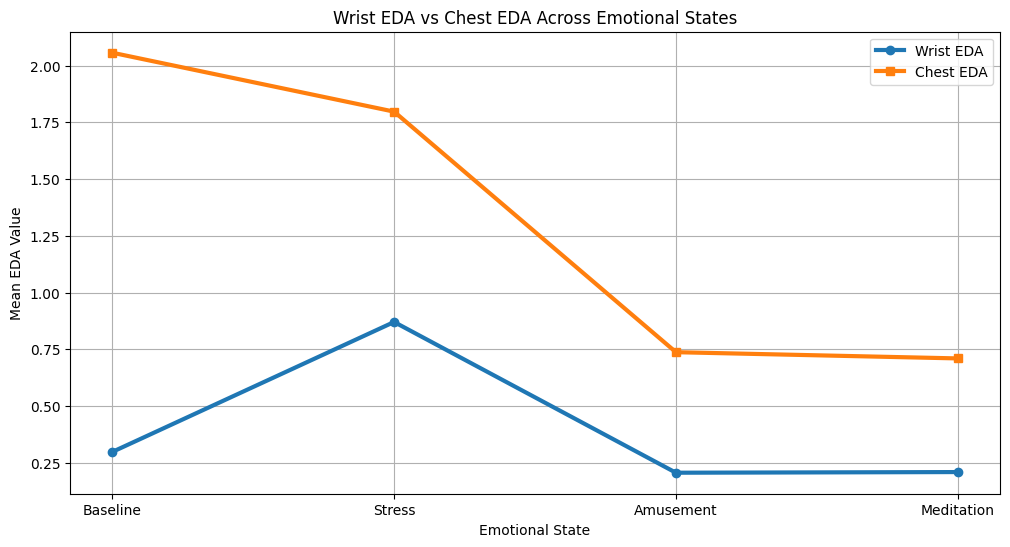

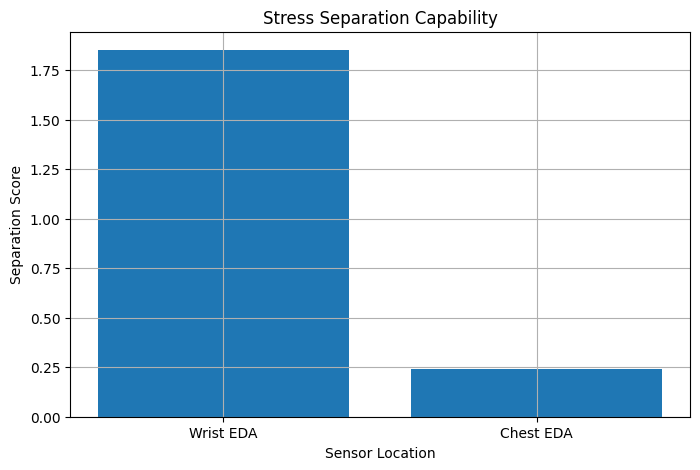

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD WESAD DATA
# ==========================================

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data['label']

# ==========================================
# WRIST EDA
# ==========================================

wrist_eda = data['signal']['wrist']['EDA'].flatten()

# Labels are 700 Hz, wrist EDA is 4 Hz
factor = len(labels) / len(wrist_eda)

indices = (np.arange(len(wrist_eda)) * factor).astype(int)
wrist_labels = labels[indices]

wrist_baseline = wrist_eda[wrist_labels == 1]
wrist_stress = wrist_eda[wrist_labels == 2]
wrist_amusement = wrist_eda[wrist_labels == 3]
wrist_meditation = wrist_eda[wrist_labels == 4]

# ==========================================
# CHEST EDA
# ==========================================

chest_eda = data['signal']['chest']['EDA'].flatten()

chest_baseline = chest_eda[labels == 1]
chest_stress = chest_eda[labels == 2]
chest_amusement = chest_eda[labels == 3]
chest_meditation = chest_eda[labels == 4]

# ==========================================
# CALCULATE MEANS
# ==========================================

states = [
    "Baseline",
    "Stress",
    "Amusement",
    "Meditation"
]

wrist_means = [
    np.mean(wrist_baseline),
    np.mean(wrist_stress),
    np.mean(wrist_amusement),
    np.mean(wrist_meditation)
]

chest_means = [
    np.mean(chest_baseline),
    np.mean(chest_stress),
    np.mean(chest_amusement),
    np.mean(chest_meditation)
]

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n===== WRIST EDA =====")
for s, m in zip(states, wrist_means):
    print(f"{s}: {m:.4f}")

print("\n===== CHEST EDA =====")
for s, m in zip(states, chest_means):
    print(f"{s}: {m:.4f}")

# ==========================================
# STRESS SEPARATION SCORE
# ==========================================

wrist_score = (
    abs(np.mean(wrist_stress) - np.mean(wrist_baseline))
    / np.std(wrist_baseline)
)

chest_score = (
    abs(np.mean(chest_stress) - np.mean(chest_baseline))
    / np.std(chest_baseline)
)

print("\n===== STRESS SEPARATION SCORE =====")
print(f"Wrist EDA : {wrist_score:.4f}")
print(f"Chest EDA : {chest_score:.4f}")

if wrist_score > chest_score:
    print("\nWrist EDA separates stress from baseline better.")
elif chest_score > wrist_score:
    print("\nChest EDA separates stress from baseline better.")
else:
    print("\nBoth sensors perform similarly.")

# ==========================================
# MAIN COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    states,
    wrist_means,
    marker='o',
    linewidth=3,
    label='Wrist EDA'
)

plt.plot(
    states,
    chest_means,
    marker='s',
    linewidth=3,
    label='Chest EDA'
)

plt.title("Wrist EDA vs Chest EDA Across Emotional States")
plt.xlabel("Emotional State")
plt.ylabel("Mean EDA Value")
plt.grid(True)
plt.legend()

plt.show()

# ==========================================
# SEPARATION SCORE GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    ["Wrist EDA", "Chest EDA"],
    [wrist_score, chest_score]
)

plt.title("Stress Separation Capability")
plt.xlabel("Sensor Location")
plt.ylabel("Separation Score")

plt.grid(True)

plt.show() 


===== WRIST TEMP =====
Baseline: 35.7862
Stress: 33.4421
Amusement: 34.1909
Meditation: 34.0858

===== CHEST TEMP =====
Baseline: 28.9175
Stress: 31.2184
Amusement: 32.1948
Meditation: 31.7111

===== STRESS SEPARATION SCORE =====
Wrist TEMP : 21.6157
Chest TEMP : 1.8140

Wrist temperature separates stress better.


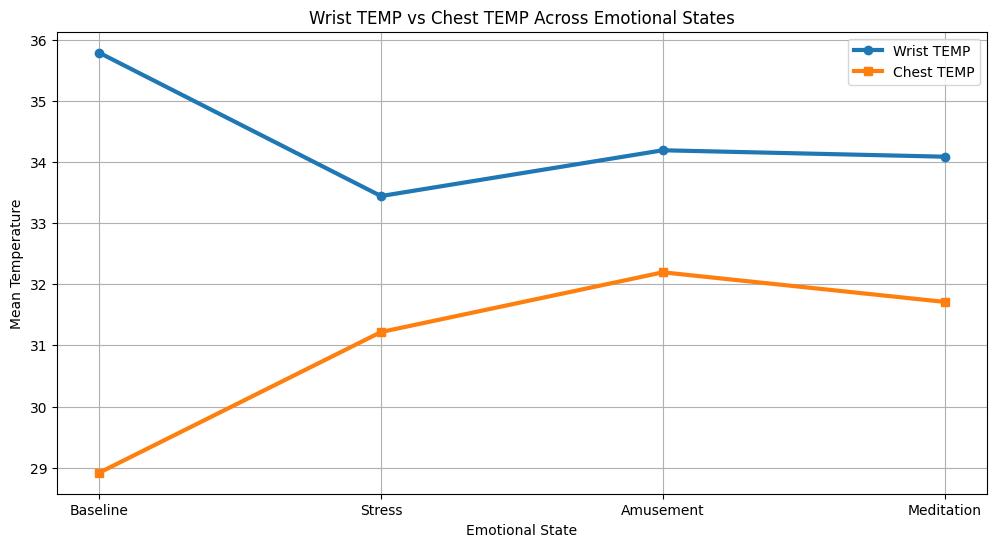

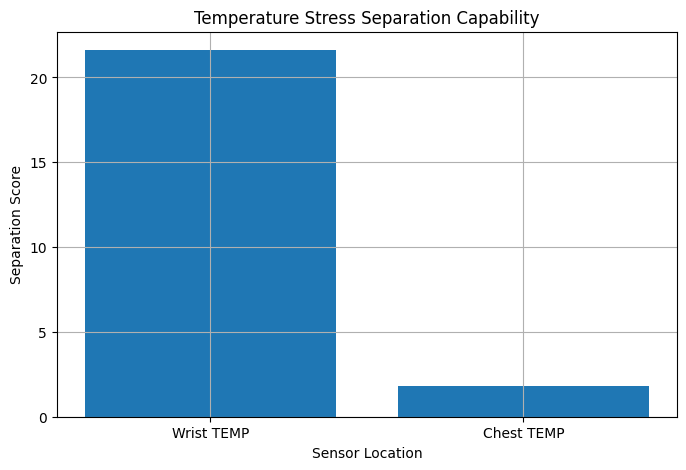

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD WESAD DATA
# ==========================================

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data['label']

# ==========================================
# WRIST TEMP
# ==========================================

wrist_temp = data['signal']['wrist']['TEMP'].flatten()

# Match labels to wrist sampling rate
factor = len(labels) / len(wrist_temp)

indices = (np.arange(len(wrist_temp)) * factor).astype(int)
wrist_labels = labels[indices]

wrist_baseline = wrist_temp[wrist_labels == 1]
wrist_stress = wrist_temp[wrist_labels == 2]
wrist_amusement = wrist_temp[wrist_labels == 3]
wrist_meditation = wrist_temp[wrist_labels == 4]

# ==========================================
# CHEST TEMP
# ==========================================

chest_temp = data['signal']['chest']['Temp'].flatten()

chest_baseline = chest_temp[labels == 1]
chest_stress = chest_temp[labels == 2]
chest_amusement = chest_temp[labels == 3]
chest_meditation = chest_temp[labels == 4]

# ==========================================
# MEAN VALUES
# ==========================================

states = [
    "Baseline",
    "Stress",
    "Amusement",
    "Meditation"
]

wrist_means = [
    np.mean(wrist_baseline),
    np.mean(wrist_stress),
    np.mean(wrist_amusement),
    np.mean(wrist_meditation)
]

chest_means = [
    np.mean(chest_baseline),
    np.mean(chest_stress),
    np.mean(chest_amusement),
    np.mean(chest_meditation)
]

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n===== WRIST TEMP =====")
for s, m in zip(states, wrist_means):
    print(f"{s}: {m:.4f}")

print("\n===== CHEST TEMP =====")
for s, m in zip(states, chest_means):
    print(f"{s}: {m:.4f}")

# ==========================================
# STRESS SEPARATION SCORE
# ==========================================

wrist_score = (
    abs(np.mean(wrist_stress) - np.mean(wrist_baseline))
    / np.std(wrist_baseline)
)

chest_score = (
    abs(np.mean(chest_stress) - np.mean(chest_baseline))
    / np.std(chest_baseline)
)

print("\n===== STRESS SEPARATION SCORE =====")
print(f"Wrist TEMP : {wrist_score:.4f}")
print(f"Chest TEMP : {chest_score:.4f}")

if wrist_score > chest_score:
    print("\nWrist temperature separates stress better.")
elif chest_score > wrist_score:
    print("\nChest temperature separates stress better.")
else:
    print("\nBoth perform similarly.")

# ==========================================
# MAIN COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    states,
    wrist_means,
    marker='o',
    linewidth=3,
    label='Wrist TEMP'
)

plt.plot(
    states,
    chest_means,
    marker='s',
    linewidth=3,
    label='Chest TEMP'
)

plt.title("Wrist TEMP vs Chest TEMP Across Emotional States")
plt.xlabel("Emotional State")
plt.ylabel("Mean Temperature")
plt.grid(True)
plt.legend()

plt.show()

# ==========================================
# SEPARATION SCORE GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    ["Wrist TEMP", "Chest TEMP"],
    [wrist_score, chest_score]
)

plt.title("Temperature Stress Separation Capability")
plt.xlabel("Sensor Location")
plt.ylabel("Separation Score")

plt.grid(True)

plt.show()


===== WRIST TEMP =====
Baseline: 35.7862
Stress: 33.4421
Amusement: 34.1909
Meditation: 34.0858

===== CHEST TEMP =====
Baseline: 28.9175
Stress: 31.2184
Amusement: 32.1948
Meditation: 31.7111

===== STRESS SEPARATION SCORE =====
Wrist TEMP : 21.6157
Chest TEMP : 1.8140


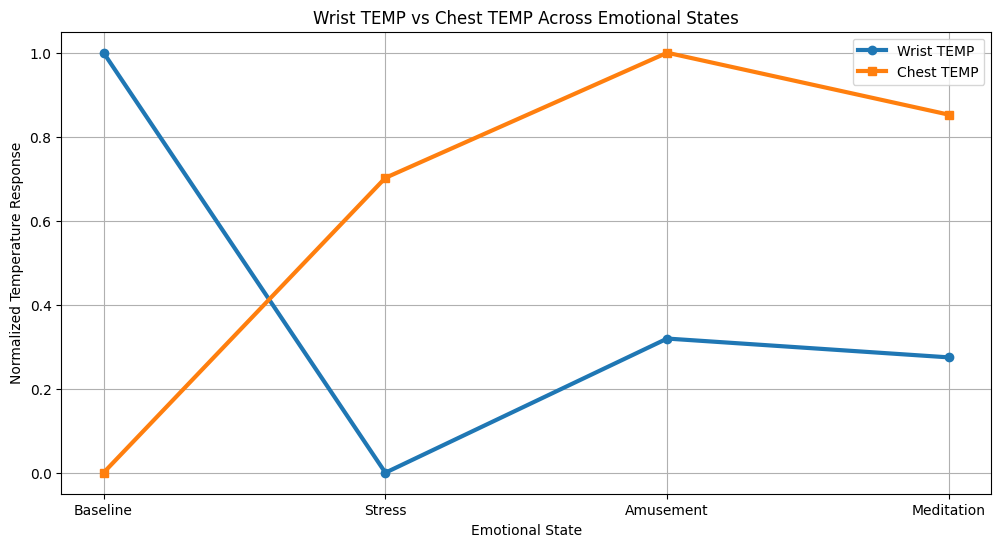

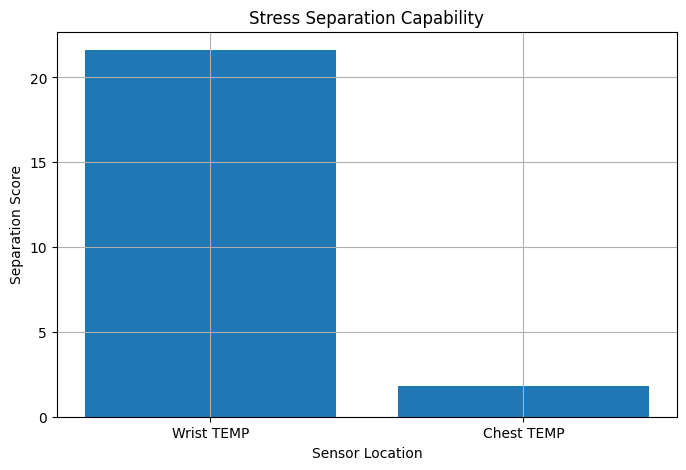

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD WESAD DATA
# ==========================================

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data['label']

# ==========================================
# WRIST TEMP
# ==========================================

wrist_temp = data['signal']['wrist']['TEMP'].flatten()

# Match labels to wrist sampling rate
factor = len(labels) / len(wrist_temp)

indices = (np.arange(len(wrist_temp)) * factor).astype(int)
wrist_labels = labels[indices]

wrist_baseline = wrist_temp[wrist_labels == 1]
wrist_stress = wrist_temp[wrist_labels == 2]
wrist_amusement = wrist_temp[wrist_labels == 3]
wrist_meditation = wrist_temp[wrist_labels == 4]

# ==========================================
# CHEST TEMP
# ==========================================

chest_temp = data['signal']['chest']['Temp'].flatten()

chest_baseline = chest_temp[labels == 1]
chest_stress = chest_temp[labels == 2]
chest_amusement = chest_temp[labels == 3]
chest_meditation = chest_temp[labels == 4]

# ==========================================
# MEAN VALUES
# ==========================================

states = [
    "Baseline",
    "Stress",
    "Amusement",
    "Meditation"
]

wrist_means = [
    np.mean(wrist_baseline),
    np.mean(wrist_stress),
    np.mean(wrist_amusement),
    np.mean(wrist_meditation)
]

chest_means = [
    np.mean(chest_baseline),
    np.mean(chest_stress),
    np.mean(chest_amusement),
    np.mean(chest_meditation)
]

print("\n===== WRIST TEMP =====")
for s, m in zip(states, wrist_means):
    print(f"{s}: {m:.4f}")

print("\n===== CHEST TEMP =====")
for s, m in zip(states, chest_means):
    print(f"{s}: {m:.4f}")

# ==========================================
# NORMALIZE FOR FAIR COMPARISON
# ==========================================

wrist_norm = (
    np.array(wrist_means) - np.min(wrist_means)
) / (
    np.max(wrist_means) - np.min(wrist_means)
)

chest_norm = (
    np.array(chest_means) - np.min(chest_means)
) / (
    np.max(chest_means) - np.min(chest_means)
)

# ==========================================
# STRESS SEPARATION SCORE
# ==========================================

wrist_score = (
    abs(np.mean(wrist_stress) - np.mean(wrist_baseline))
    / np.std(wrist_baseline)
)

chest_score = (
    abs(np.mean(chest_stress) - np.mean(chest_baseline))
    / np.std(chest_baseline)
)

print("\n===== STRESS SEPARATION SCORE =====")
print(f"Wrist TEMP : {wrist_score:.4f}")
print(f"Chest TEMP : {chest_score:.4f}")

# ==========================================
# MAIN COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    states,
    wrist_norm,
    marker='o',
    linewidth=3,
    label='Wrist TEMP'
)

plt.plot(
    states,
    chest_norm,
    marker='s',
    linewidth=3,
    label='Chest TEMP'
)

plt.title("Wrist TEMP vs Chest TEMP Across Emotional States")

plt.xlabel("Emotional State")
plt.ylabel("Normalized Temperature Response")

plt.grid(True)
plt.legend()

plt.show()

# ==========================================
# SEPARATION SCORE GRAPH
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    ["Wrist TEMP", "Chest TEMP"],
    [wrist_score, chest_score]
)

plt.title("Stress Separation Capability")

plt.xlabel("Sensor Location")
plt.ylabel("Separation Score")

plt.grid(True)

plt.show()

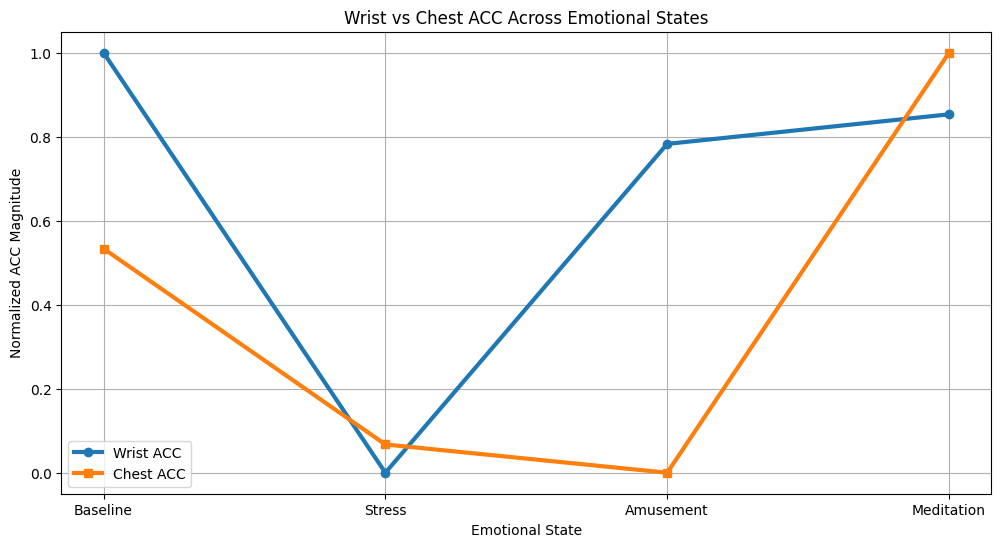


===== WRIST ACC =====
Baseline: 63.3767
Stress: 62.9370
Amusement: 63.2813
Meditation: 63.3122

===== CHEST ACC =====
Baseline: 0.9502
Stress: 0.9295
Amusement: 0.9265
Meditation: 0.9709


In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ====================================
# LOAD DATA
# ====================================

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data['label']

# ====================================
# WRIST ACC
# ====================================

wrist_acc = data['signal']['wrist']['ACC']

wrist_mag = np.sqrt(
    wrist_acc[:,0]**2 +
    wrist_acc[:,1]**2 +
    wrist_acc[:,2]**2
)

# ====================================
# CHEST ACC
# ====================================

chest_acc = data['signal']['chest']['ACC']

chest_mag = np.sqrt(
    chest_acc[:,0]**2 +
    chest_acc[:,1]**2 +
    chest_acc[:,2]**2
)

# ====================================
# MATCH LABELS
# ====================================

wrist_idx = np.linspace(
    0,
    len(labels)-1,
    len(wrist_mag)
).astype(int)

wrist_labels = labels[wrist_idx]

chest_idx = np.linspace(
    0,
    len(labels)-1,
    len(chest_mag)
).astype(int)

chest_labels = labels[chest_idx]

# ====================================
# STATES
# ====================================

states = ["Baseline","Stress","Amusement","Meditation"]

wrist_means = [
    np.mean(wrist_mag[wrist_labels == 1]),
    np.mean(wrist_mag[wrist_labels == 2]),
    np.mean(wrist_mag[wrist_labels == 3]),
    np.mean(wrist_mag[wrist_labels == 4])
]

chest_means = [
    np.mean(chest_mag[chest_labels == 1]),
    np.mean(chest_mag[chest_labels == 2]),
    np.mean(chest_mag[chest_labels == 3]),
    np.mean(chest_mag[chest_labels == 4])
]

# ====================================
# NORMALIZE
# ====================================

wrist_norm = (
    np.array(wrist_means) - np.min(wrist_means)
) / (
    np.max(wrist_means) - np.min(wrist_means)
)

chest_norm = (
    np.array(chest_means) - np.min(chest_means)
) / (
    np.max(chest_means) - np.min(chest_means)
)

# ====================================
# COMPARISON GRAPH
# ====================================

plt.figure(figsize=(12,6))

plt.plot(
    states,
    wrist_norm,
    marker='o',
    linewidth=3,
    label='Wrist ACC'
)

plt.plot(
    states,
    chest_norm,
    marker='s',
    linewidth=3,
    label='Chest ACC'
)

plt.title("Wrist vs Chest ACC Across Emotional States")

plt.xlabel("Emotional State")
plt.ylabel("Normalized ACC Magnitude")

plt.legend()
plt.grid(True)

plt.show()

# ====================================
# PRINT VALUES
# ====================================

print("\n===== WRIST ACC =====")
for s, v in zip(states, wrist_means):
    print(f"{s}: {v:.4f}")

print("\n===== CHEST ACC =====")
for s, v in zip(states, chest_means):
    print(f"{s}: {v:.4f}")


========== WRIST ACC ==========
Baseline      Mean=63.3767  Std=3.3864
Stress        Mean=62.9370  Std=2.7372
Amusement     Mean=63.2813  Std=1.5143
Meditation    Mean=63.3122  Std=0.4051

========== CHEST ACC ==========
Baseline      Mean=0.9502  Std=0.0144
Stress        Mean=0.9295  Std=0.0114
Amusement     Mean=0.9265  Std=0.0047
Meditation    Mean=0.9709  Std=0.0117

========== STRESS SEPARATION ==========
Wrist ACC : 0.1298
Chest ACC : 1.4384

Chest ACC separates stress better.


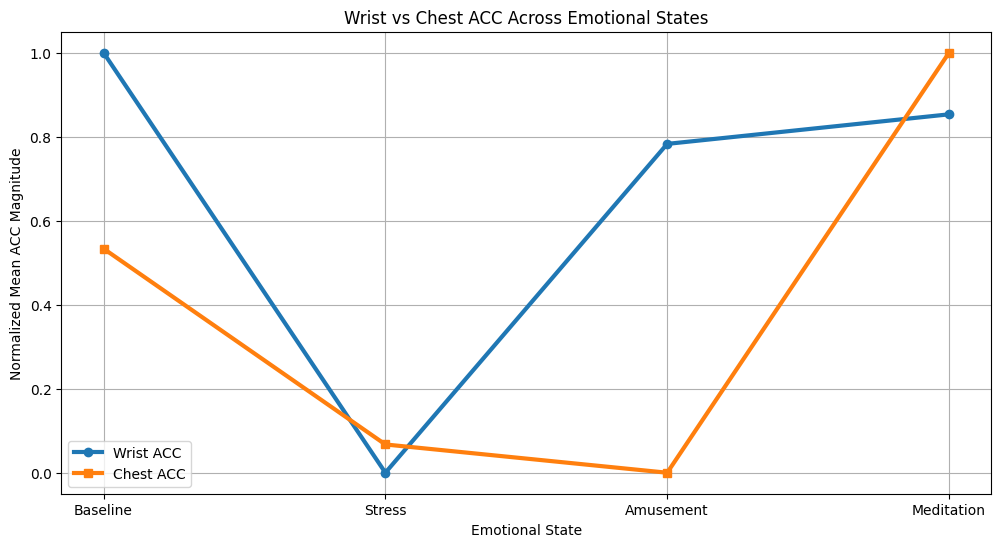

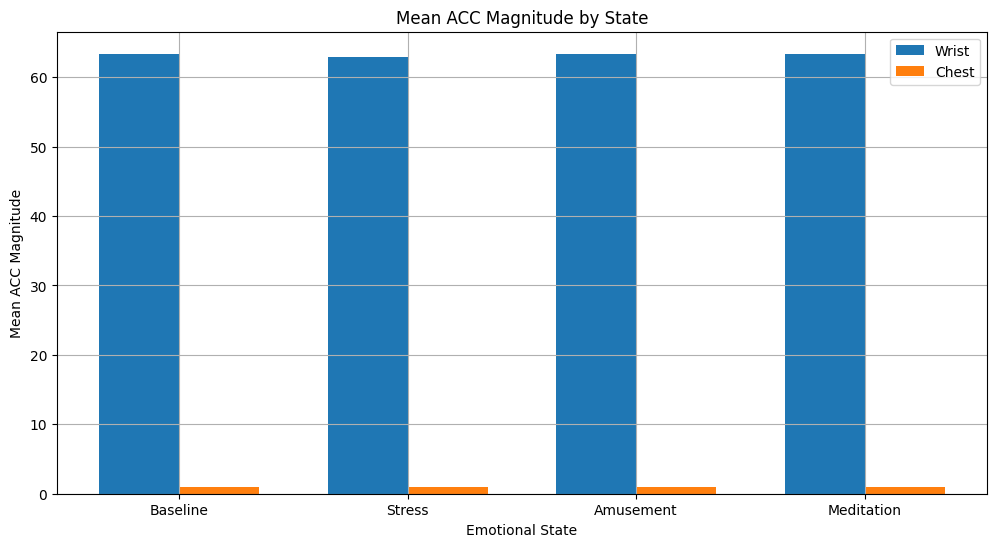

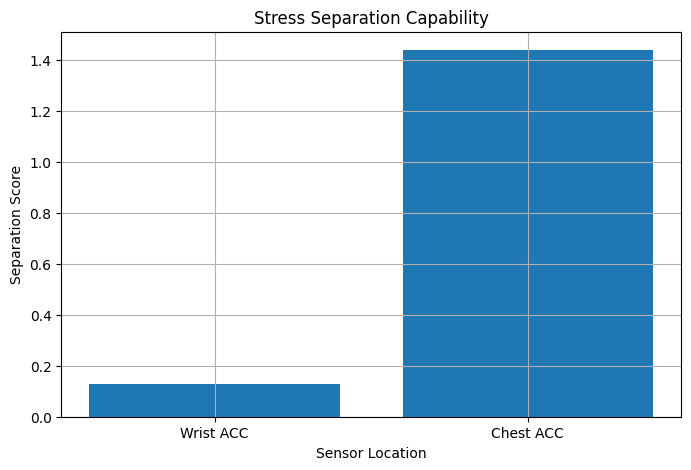

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

labels = data["label"]

# ==========================================
# WRIST ACC
# ==========================================

wrist_acc = data["signal"]["wrist"]["ACC"]

wrist_mag = np.sqrt(
    wrist_acc[:,0]**2 +
    wrist_acc[:,1]**2 +
    wrist_acc[:,2]**2
)

# ==========================================
# CHEST ACC
# ==========================================

chest_acc = data["signal"]["chest"]["ACC"]

chest_mag = np.sqrt(
    chest_acc[:,0]**2 +
    chest_acc[:,1]**2 +
    chest_acc[:,2]**2
)

# ==========================================
# MATCH LABELS
# ==========================================

wrist_idx = np.linspace(
    0,
    len(labels)-1,
    len(wrist_mag)
).astype(int)

wrist_labels = labels[wrist_idx]

chest_idx = np.linspace(
    0,
    len(labels)-1,
    len(chest_mag)
).astype(int)

chest_labels = labels[chest_idx]

# ==========================================
# EXTRACT STATES
# ==========================================

def state_values(signal, lbls, state):
    return signal[lbls == state]

# Wrist
wrist_baseline   = state_values(wrist_mag, wrist_labels, 1)
wrist_stress     = state_values(wrist_mag, wrist_labels, 2)
wrist_amusement  = state_values(wrist_mag, wrist_labels, 3)
wrist_meditation = state_values(wrist_mag, wrist_labels, 4)

# Chest
chest_baseline   = state_values(chest_mag, chest_labels, 1)
chest_stress     = state_values(chest_mag, chest_labels, 2)
chest_amusement  = state_values(chest_mag, chest_labels, 3)
chest_meditation = state_values(chest_mag, chest_labels, 4)

# ==========================================
# MEANS
# ==========================================

states = [
    "Baseline",
    "Stress",
    "Amusement",
    "Meditation"
]

wrist_means = [
    np.mean(wrist_baseline),
    np.mean(wrist_stress),
    np.mean(wrist_amusement),
    np.mean(wrist_meditation)
]

chest_means = [
    np.mean(chest_baseline),
    np.mean(chest_stress),
    np.mean(chest_amusement),
    np.mean(chest_meditation)
]

# ==========================================
# STANDARD DEVIATIONS
# ==========================================

wrist_stds = [
    np.std(wrist_baseline),
    np.std(wrist_stress),
    np.std(wrist_amusement),
    np.std(wrist_meditation)
]

chest_stds = [
    np.std(chest_baseline),
    np.std(chest_stress),
    np.std(chest_amusement),
    np.std(chest_meditation)
]

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n========== WRIST ACC ==========")

for s, m, sd in zip(states, wrist_means, wrist_stds):
    print(
        f"{s:12s}  Mean={m:.4f}  Std={sd:.4f}"
    )

print("\n========== CHEST ACC ==========")

for s, m, sd in zip(states, chest_means, chest_stds):
    print(
        f"{s:12s}  Mean={m:.4f}  Std={sd:.4f}"
    )

# ==========================================
# SEPARATION SCORES
# ==========================================

wrist_sep = abs(
    np.mean(wrist_stress) -
    np.mean(wrist_baseline)
) / np.std(wrist_baseline)

chest_sep = abs(
    np.mean(chest_stress) -
    np.mean(chest_baseline)
) / np.std(chest_baseline)

print("\n========== STRESS SEPARATION ==========")

print(f"Wrist ACC : {wrist_sep:.4f}")
print(f"Chest ACC : {chest_sep:.4f}")

if wrist_sep > chest_sep:
    print("\nWrist ACC separates stress better.")
else:
    print("\nChest ACC separates stress better.")

# ==========================================
# NORMALIZE MEANS
# ==========================================

wrist_norm = (
    np.array(wrist_means) -
    np.min(wrist_means)
) / (
    np.max(wrist_means) -
    np.min(wrist_means)
)

chest_norm = (
    np.array(chest_means) -
    np.min(chest_means)
) / (
    np.max(chest_means) -
    np.min(chest_means)
)

# ==========================================
# GRAPH 1
# STATE COMPARISON
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    states,
    wrist_norm,
    marker="o",
    linewidth=3,
    label="Wrist ACC"
)

plt.plot(
    states,
    chest_norm,
    marker="s",
    linewidth=3,
    label="Chest ACC"
)

plt.title(
    "Wrist vs Chest ACC Across Emotional States"
)

plt.xlabel("Emotional State")
plt.ylabel("Normalized Mean ACC Magnitude")

plt.grid(True)
plt.legend()

plt.show()

# ==========================================
# GRAPH 2
# RAW MEAN VALUES
# ==========================================

x = np.arange(len(states))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    wrist_means,
    width,
    label="Wrist"
)

plt.bar(
    x + width/2,
    chest_means,
    width,
    label="Chest"
)

plt.xticks(x, states)

plt.title(
    "Mean ACC Magnitude by State"
)

plt.xlabel("Emotional State")
plt.ylabel("Mean ACC Magnitude")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# GRAPH 3
# SEPARATION SCORE
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    ["Wrist ACC", "Chest ACC"],
    [wrist_sep, chest_sep]
)

plt.title(
    "Stress Separation Capability"
)

plt.xlabel("Sensor Location")
plt.ylabel("Separation Score")

plt.grid(True)

plt.show()